# Transient Operator Learning: Data-Driven vs. Weighted-Residual

*A direct, like-for-like comparison of the two transient FNOs from the previous two chapters. Both learn the same one-step operator for the nonlinear heat equation; they differ only in how they were trained — one on FEM labels, one on the label-free weighted residual. We summarize the difference with a single curve: the mean rollout error at each time step.*

---

This notebook is self-contained. It (1) generates the transient FEM dataset once, (2) trains the **data-driven** FNO and the **weighted-residual** FNO on identical data, (3) rolls both forward autoregressively on the unseen test set, and (4) plots the **mean absolute error per time step** for each — a compact replacement for the per-step box plots.

It then repeats the comparison on **50 out-of-distribution scenarios** (unseen initial-field shapes and higher-frequency materials), where a physics-trained operator is expected to generalize better.

The training budget `EPOCHS` is set modestly so the comparison runs quickly; raise it to match the individual chapters if you want fully converged curves.

In [1]:
# ============================================================
# 1. Config + physics (FEM) + FNO model + weak-form residual
#    (identical to the two transient chapters, gathered here)
# ============================================================
import jax, jax.numpy as jnp, optax
import numpy as np, matplotlib.pyplot as plt

N_GRID=64; N_NODES=N_GRID+1; WIDTH=64; MODES=8
BATCH_SIZE=32; N_SAMPLES=300; TRAIN_SAMPLES=240; VAL_SAMPLES=30
MAX_STEPS=20; DT=0.02; RHO_CP=5.0
GRID=jnp.linspace(0,1,N_NODES)
EPOCHS=1500          # modest preview; raise (e.g. 6000-10001) for smoother curves

@jax.jit
def generate_smooth_fn(key):
    x=jnp.linspace(0,1,N_NODES); k1,k2=jax.random.split(key,2)
    f=jax.random.uniform(k1,(3,),minval=1.0,maxval=3.0); a=jax.random.uniform(k2,(3,),minval=0.1,maxval=0.3)
    return jnp.sum(a[:,None]*jnp.sin(f[:,None]*jnp.pi*x),axis=0)

@jax.jit
def generate_complex_fn(key):
    x=jnp.linspace(0,1,N_NODES); k1,k2,k3,k4=jax.random.split(key,4)
    f=jax.random.uniform(k1,(3,),minval=1.0,maxval=3.0); a=jax.random.uniform(k2,(3,),minval=0.1,maxval=0.3)
    smooth=jnp.sum(a[:,None]*jnp.sin(f[:,None]*jnp.pi*x),axis=0)
    ep=jax.random.uniform(k3,(),minval=0.2,maxval=0.8); eh=jax.random.uniform(k4,(),minval=-0.3,maxval=0.3)
    return smooth+jnp.where(x<ep,eh,0.0)

@jax.jit
def solve_transient_fem_step(T_n, alpha_x):
    dx=1.0/N_GRID; K=jnp.zeros((N_NODES,N_NODES)); M=jnp.zeros((N_NODES,N_NODES))
    k_nodal=alpha_x*(0.5+T_n**2)
    for e in range(N_GRID):
        ix=jnp.array([e,e+1]); k_avg=0.5*(k_nodal[e]+k_nodal[e+1])
        ke=(k_avg/dx)*jnp.array([[1.,-1.],[-1.,1.]]); me=(RHO_CP*dx/6.0)*jnp.array([[2.,1.],[1.,2.]])
        K=K.at[jnp.ix_(ix,ix)].add(ke); M=M.at[jnp.ix_(ix,ix)].add(me)
    LHS=M+DT*K; RHS=M@T_n; free=jnp.arange(1,N_NODES-1)
    RHS_free=RHS[free]-LHS[free,0]*1.0-LHS[free,-1]*0.0
    Tf=jnp.linalg.solve(LHS[jnp.ix_(free,free)],RHS_free)
    return jnp.zeros(N_NODES).at[0].set(1.0).at[-1].set(0.0).at[free].set(Tf)

@jax.jit
def compute_weak_residual(T_next, T_curr, alpha_x):
    dx=1.0/N_GRID; K=jnp.zeros((N_NODES,N_NODES)); M=jnp.zeros((N_NODES,N_NODES))
    k_nodal=alpha_x*(0.5+T_curr**2)
    for e in range(N_GRID):
        ix=jnp.array([e,e+1]); k_avg=0.5*(k_nodal[e]+k_nodal[e+1])
        ke=(k_avg/dx)*jnp.array([[1.,-1.],[-1.,1.]]); me=(RHO_CP*dx/6.0)*jnp.array([[2.,1.],[1.,2.]])
        K=K.at[jnp.ix_(ix,ix)].add(ke); M=M.at[jnp.ix_(ix,ix)].add(me)
    LHS=M+DT*K; RHS=M@T_curr; free=jnp.arange(1,N_NODES-1)
    return (LHS@T_next-RHS)[free]

@jax.jit
def generate_trajectory(key_k,key_t):
    alpha=jax.nn.sigmoid(generate_smooth_fn(key_k))*0.4+0.1
    T0s=generate_complex_fn(key_t); ramp=jnp.linspace(1.0,0.0,N_NODES)
    mask=jnp.sin(jnp.pi*jnp.linspace(0,1,N_NODES)); T0=ramp+(T0s*mask)
    def step(Tc,_):
        Tn=solve_transient_fem_step(Tc,alpha); return Tn,(Tc,Tn)
    _,(inp,tgt)=jax.lax.scan(step,T0,None,length=MAX_STEPS-1)
    return inp,tgt,alpha,T0

def fem_rollout(T0,alpha,steps):
    def step(Tc,_): v=solve_transient_fem_step(Tc,alpha); return v,v
    return jnp.vstack([T0,jax.lax.scan(step,T0,None,length=steps)[1]])

# ---- FNO ----
def spectral_layer(x,w_spec,w_skip):
    n=x.shape[0]; xf=jnp.fft.rfft(x,axis=0)
    of=jnp.zeros_like(xf,dtype=jnp.complex64).at[:MODES].set(jnp.einsum('mi,mij->mj',xf[:MODES],w_spec))
    return jax.nn.gelu(jnp.fft.irfft(of,n=n,axis=0)+jnp.dot(x,w_skip))

def fno_model(params,x_norm,T_curr):
    x=jax.nn.gelu(jnp.dot(x_norm,params[0])+params[1])
    for i in range(2,10,2): x=spectral_layer(x,params[i],params[i+1])
    x=jax.nn.gelu(jnp.dot(x,params[10])+params[11])
    res=(jnp.dot(x,params[12])+params[13]).squeeze()
    mask=jnp.sin(jnp.pi*jnp.linspace(0,1,N_NODES))
    return T_curr+(res*mask)

def init_params(key):
    keys=jax.random.split(key,12)
    def ni(k,s): return jax.random.normal(k,s)*jnp.sqrt(1.0/s[-1])
    p=[ni(keys[0],(3,WIDTH)),jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1],(MODES,WIDTH,WIDTH),dtype=jnp.complex64)*0.02)
        p.append(ni(keys[i+5],(WIDTH,WIDTH)))
    p.extend([ni(keys[10],(WIDTH,WIDTH)),jnp.zeros(WIDTH),ni(keys[11],(WIDTH,1)),jnp.zeros(1)])
    return p
print("physics + model ready")

physics + model ready


## 2. Shared dataset

One FEM dataset is generated and used to train both models, so the comparison is fair.

In [2]:
# ============================================================
# 2. Generate the shared FEM dataset (used by BOTH models)
# ============================================================
keys_k=jax.random.split(jax.random.PRNGKey(42),N_SAMPLES)
keys_t=jax.random.split(jax.random.PRNGKey(7),N_SAMPLES)
all_X,all_Y,all_A,all_T0=jax.vmap(generate_trajectory)(keys_k,keys_t)

grid_exp=jnp.tile(GRID,(N_SAMPLES,MAX_STEPS-1,1))
X_raw=jnp.stack([all_X,jnp.tile(all_A[:,None,:],(1,MAX_STEPS-1,1)),grid_exp],axis=-1)
Y_raw=all_Y[...,None]
X_tr=X_raw[:TRAIN_SAMPLES].reshape(-1,N_NODES,3)
Y_tr=Y_raw[:TRAIN_SAMPLES].reshape(-1,N_NODES,1)
x_mean,x_std=X_tr.mean(axis=(0,1)),X_tr.std(axis=(0,1))+1e-7
X_tr_n=(X_tr-x_mean)/x_std
print("dataset:",X_tr.shape[0],"one-step training pairs")

dataset: 4560 one-step training pairs


## 3. Train both operators

Identical network, data, optimizer, and epoch budget — only the loss differs.

In [3]:
# ============================================================
# 3. Train BOTH models on the same data
#    (a) data-driven  = MSE against FEM target
#    (b) weighted-res = Galerkin residual, no labels
# ============================================================
def make_opt():
    sched=optax.cosine_decay_schedule(init_value=1e-3,decay_steps=EPOCHS,alpha=1e-2)
    return optax.adamw(learning_rate=sched,weight_decay=1e-4)

def train(mode):
    params=init_params(jax.random.PRNGKey(123)); opt=make_opt(); opt_state=opt.init(params)
    @jax.jit
    def step(p,os_,bXn,bXr,bY):
        Tc=bXr[:,:,0]; al=bXr[:,:,1]
        def loss(p):
            pred=jax.vmap(fno_model,(None,0,0))(p,bXn,Tc)
            if mode=="data":
                return jnp.mean((pred-bY.squeeze())**2)
            r=jax.vmap(compute_weak_residual,(0,0,0))(pred,Tc,al)
            r=jax.lax.stop_gradient(r)
            return jnp.mean(jnp.sum(pred[:,1:-1]*r,axis=1))
        l,g=jax.value_and_grad(loss)(p); u,os_=opt.update(g,os_,p)
        return optax.apply_updates(p,u),os_,l
    for i in range(EPOCHS):
        idx=jax.random.randint(jax.random.PRNGKey(i),(BATCH_SIZE,),0,X_tr.shape[0])
        params,opt_state,l=step(params,opt_state,X_tr_n[idx],X_tr[idx],Y_tr[idx])
        if i%1000==0: print(f"  [{mode:<9}] epoch {i:5d}  loss {float(l): .3e}")
    return params

print("Training data-driven model ..."); params_data=train("data")
print("Training weighted-residual model ..."); params_wres=train("wres")
print("both models trained")

Training data-driven model ...


  [data     ] epoch     0  loss  8.728e-05


  [data     ] epoch  1000  loss  6.030e-06


Training weighted-residual model ...


  [wres     ] epoch     0  loss -2.475e-04


  [wres     ] epoch  1000  loss -9.884e-04


both models trained


## 4. The single comparison curve

Both trained operators are rolled forward autoregressively on the unseen test set. For each time step we take the absolute error, averaged over all spatial nodes and all test trajectories — giving one mean-error value per step, per model. Two lines summarize the whole comparison: where they separate is where the two training strategies start to differ.

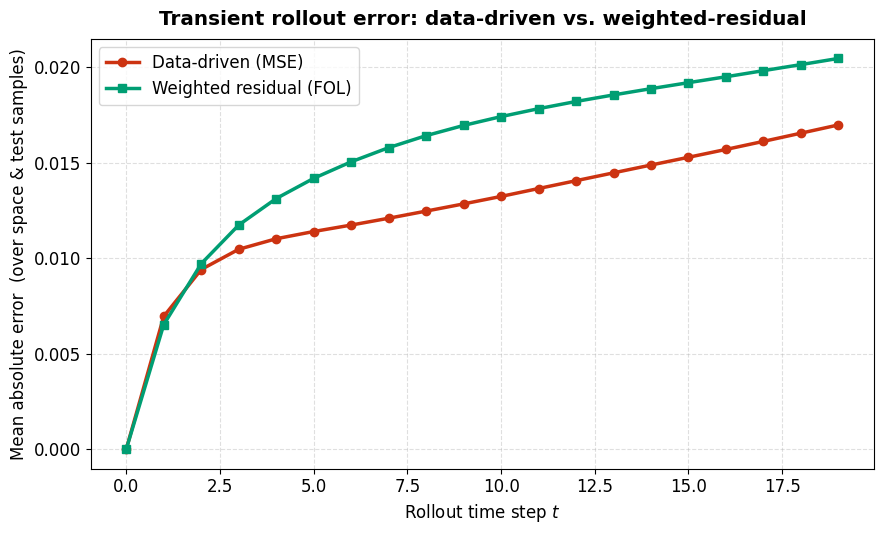

final-step mean error  |  data-driven: 1.698e-02   weighted: 2.047e-02


In [4]:
# ============================================================
# 5. Roll out both models on the unseen TEST set and plot the
#    MEAN absolute error at each rollout time step (one curve each)
# ============================================================
from functools import partial

@partial(jax.jit,static_argnums=(3,))
def batch_rollout(p,T0b,ab,steps):
    def step(Tc,_):
        gb=jnp.tile(GRID,(T0b.shape[0],1))
        xn=(jnp.stack([Tc,ab,gb],axis=-1)-x_mean)/x_std
        Tn=jax.vmap(fno_model,(None,0,0))(p,xn,Tc); return Tn,Tn
    _,tr=jax.lax.scan(step,T0b,None,length=steps)
    return jnp.concatenate([T0b[:,None,:],jnp.transpose(tr,(1,0,2))],axis=1)

# ground-truth test trajectories
true_all=jnp.concatenate([all_T0[:,None,:],all_Y],axis=1)
true_test=true_all[TRAIN_SAMPLES:]
T0_test,A_test=all_T0[TRAIN_SAMPLES:],all_A[TRAIN_SAMPLES:]

pred_data=batch_rollout(params_data,T0_test,A_test,MAX_STEPS-1)
pred_wres=batch_rollout(params_wres,T0_test,A_test,MAX_STEPS-1)

# mean over spatial nodes AND over test samples -> one value per time step
mean_err_data=np.asarray(jnp.mean(jnp.abs(true_test-pred_data),axis=(0,2)))
mean_err_wres=np.asarray(jnp.mean(jnp.abs(true_test-pred_wres),axis=(0,2)))
steps=np.arange(MAX_STEPS)

plt.rcParams.update({'font.size':12})
fig,ax=plt.subplots(figsize=(9,5.5))
ax.plot(steps,mean_err_data,color='#CC3311',marker='o',lw=2.5,label='Data-driven (MSE)')
ax.plot(steps,mean_err_wres,color='#009E73',marker='s',lw=2.5,label='Weighted residual (FOL)')
ax.set_xlabel("Rollout time step $t$"); ax.set_ylabel("Mean absolute error  (over space & test samples)")
ax.set_title("Transient rollout error: data-driven vs. weighted-residual",fontweight='bold',pad=10)
ax.grid(True,ls='--',alpha=0.4); ax.legend()
plt.tight_layout(); plt.savefig("transient_mean_error_comparison.png",dpi=150,bbox_inches='tight'); plt.show()

print(f"final-step mean error  |  data-driven: {mean_err_data[-1]:.3e}   weighted: {mean_err_wres[-1]:.3e}")

## 5. Out-of-distribution comparison (unseen shapes + super-resolution)

To match the steady-state study, the transient OOD test varies **two axes at once**:

- **Unseen shapes** — initial fields the models never trained on (top-hats, high-frequency oscillations, sawtooths, staircases, sharp spikes) on higher-frequency materials.
- **Super-resolution** — the scenarios are generated on **finer grids than training** (node counts `[65, 96, 128, 160, 192, 256]`), with the FEM ground truth solved at each resolution and both operators rolled out there. The FNO's spectral layers are resolution-independent, so the same trained weights apply directly at any grid size.

We build 50 such scenarios, roll both operators forward, and plot the mean absolute error per rollout step. This is where a physics-anchored operator is expected to generalize best.

In [5]:
# ---- resolution-aware FEM step, OOD builders, and FNO rollout ----
RES_CHOICES = [N_NODES, 96, 128, 160, 192, 256]   # node counts (training = 65)
N_OOD = 50

def fem_step_n(T_n, alpha_x, n_grid):
    n_nodes = n_grid + 1; dx = 1.0 / n_grid
    k_nodal = alpha_x * (0.5 + T_n**2)
    k_avg = 0.5 * (k_nodal[:-1] + k_nodal[1:])
    e = jnp.arange(n_grid)
    rows = jnp.stack([e, e, e+1, e+1], axis=1).reshape(-1)
    cols = jnp.stack([e, e+1, e, e+1], axis=1).reshape(-1)
    k_loc = (k_avg[:, None] / dx) * jnp.array([1., -1., -1., 1.])[None, :]
    m_loc = (RHO_CP * dx / 6.0) * jnp.broadcast_to(jnp.array([2., 1., 1., 2.]), (n_grid, 4))
    K = jnp.zeros((n_nodes, n_nodes)).at[rows, cols].add(k_loc.reshape(-1))
    M = jnp.zeros((n_nodes, n_nodes)).at[rows, cols].add(m_loc.reshape(-1))
    LHS = M + DT * K; RHS = M @ T_n; free = jnp.arange(1, n_nodes - 1)
    RHS_free = RHS[free] - LHS[free, 0] * 1.0 - LHS[free, -1] * 0.0
    Tf = jnp.linalg.solve(LHS[jnp.ix_(free, free)], RHS_free)
    return jnp.zeros(n_nodes).at[0].set(1.0).at[-1].set(0.0).at[free].set(Tf)

def ood_fields_n(key, kind, n_nodes):
    x = jnp.linspace(0, 1, n_nodes); mask = jnp.sin(jnp.pi * x); ramp = jnp.linspace(1., 0., n_nodes)
    k = jax.random.split(key, 6)
    f = jax.random.uniform(k[0], (3,), minval=4.0, maxval=8.0)      # higher-freq (OOD) material
    a = jax.random.uniform(k[1], (3,), minval=0.1, maxval=0.3)
    alpha = jax.nn.sigmoid(jnp.sum(a[:, None]*jnp.sin(f[:, None]*jnp.pi*x[None, :]), axis=0))*0.4+0.1
    if kind == 0:      c=jax.random.uniform(k[2],(),minval=0.3,maxval=0.7); w=jax.random.uniform(k[3],(),minval=0.1,maxval=0.25); A=jax.random.uniform(k[4],(),minval=0.3,maxval=0.8); pert=jnp.where(jnp.abs(x-c)<w,A,0.)
    elif kind == 1:    kf=jax.random.uniform(k[2],(),minval=8.,maxval=12.); A=jax.random.uniform(k[3],(),minval=0.2,maxval=0.5); pert=A*jnp.sin(kf*jnp.pi*x)
    elif kind == 2:    kf=jax.random.uniform(k[2],(),minval=3.,maxval=6.); A=jax.random.uniform(k[3],(),minval=0.2,maxval=0.5); pert=A*(2.*(x*kf-jnp.floor(x*kf+0.5)))
    elif kind == 3:    nn=jax.random.uniform(k[2],(),minval=3.,maxval=6.); A=jax.random.uniform(k[3],(),minval=0.2,maxval=0.5); pert=A*(jnp.floor(x*nn)/nn-0.5)*2.
    else:              c=jax.random.uniform(k[2],(),minval=0.3,maxval=0.7); A=jax.random.uniform(k[3],(),minval=0.4,maxval=0.9); pert=A*jnp.exp(-((x-c)**2)/(2*0.03**2))
    return ramp + mask * pert, alpha

def fem_rollout_n(T0, alpha, n_grid):
    def step(Tc, _): v = fem_step_n(Tc, alpha, n_grid); return v, v
    _, tr = jax.lax.scan(step, T0, None, length=MAX_STEPS-1)
    return jnp.vstack([T0, tr])

def rollout_fno_n(p, T0, alpha, n_nodes):
    grid = jnp.linspace(0, 1, n_nodes); mask = jnp.sin(jnp.pi * grid)
    def model(Tc):
        xn = (jnp.stack([Tc, alpha, grid], axis=-1) - x_mean) / x_std
        h = jax.nn.gelu(jnp.dot(xn, p[0]) + p[1])
        for i in range(2, 10, 2): h = spectral_layer(h, p[i], p[i+1])
        h = jax.nn.gelu(jnp.dot(h, p[10]) + p[11])
        res = (jnp.dot(h, p[12]) + p[13]).squeeze()
        return Tc + res * mask
    def step(Tc, _): v = model(Tc); return v, v
    _, tr = jax.lax.scan(step, T0, None, length=MAX_STEPS-1)
    return jnp.vstack([T0, tr])

# build 50 OOD scenarios spread across resolutions and shape families
scenarios = []
for i in range(N_OOD):
    n_nodes = RES_CHOICES[i % len(RES_CHOICES)]; n_grid = n_nodes - 1
    key = jax.random.PRNGKey(2000 + i)
    T0, alpha = ood_fields_n(key, i % 5, n_nodes)
    scenarios.append((T0, alpha, n_grid, n_nodes))
print(f"built {len(scenarios)} OOD scenarios across resolutions {RES_CHOICES}")

built 50 OOD scenarios across resolutions [65, 96, 128, 160, 192, 256]


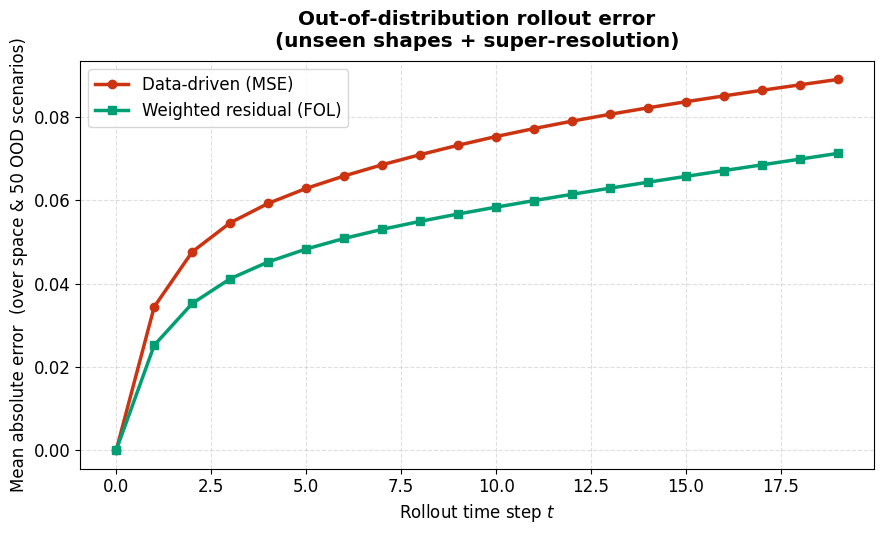

OOD final-step mean error | data-driven: 8.904e-02   weighted: 7.127e-02


In [6]:
# ---- roll both models on every OOD scenario; mean error per step ----
err_data, err_wres = [], []
for (T0, alpha, n_grid, n_nodes) in scenarios:
    true  = fem_rollout_n(T0, alpha, n_grid)
    pd    = rollout_fno_n(params_data, T0, alpha, n_nodes)
    pw    = rollout_fno_n(params_wres, T0, alpha, n_nodes)
    err_data.append(np.asarray(jnp.mean(jnp.abs(true - pd), axis=1)))   # per-step, mean over nodes
    err_wres.append(np.asarray(jnp.mean(jnp.abs(true - pw), axis=1)))

mean_err_data_ood = np.mean(np.stack(err_data), axis=0)   # average over the 50 scenarios
mean_err_wres_ood = np.mean(np.stack(err_wres), axis=0)
steps = np.arange(MAX_STEPS)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(steps, mean_err_data_ood, color='#CC3311', marker='o', lw=2.5, label='Data-driven (MSE)')
ax.plot(steps, mean_err_wres_ood, color='#009E73', marker='s', lw=2.5, label='Weighted residual (FOL)')
ax.set_xlabel("Rollout time step $t$")
ax.set_ylabel("Mean absolute error  (over space & 50 OOD scenarios)")
ax.set_title("Out-of-distribution rollout error\n(unseen shapes + super-resolution)", fontweight='bold', pad=10)
ax.grid(True, ls='--', alpha=0.4); ax.legend()
plt.tight_layout(); plt.savefig("transient_ood_superres.png", dpi=150, bbox_inches='tight'); plt.show()
print(f"OOD final-step mean error | data-driven: {mean_err_data_ood[-1]:.3e}   weighted: {mean_err_wres_ood[-1]:.3e}")